In [38]:
%pip install -U numpy control
%pip install scipy
%load_ext autoreload 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
%reload_ext autoreload
%autoreload 2
import sys
import control as ct
import numpy as np
import param as param
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# autoreload can leave stale function refs after edits; force a clean import
sys.modules.pop("dynamics", None)
import dynamics as dyn

params = param.params

# 5.2

In [40]:
# Analyze LTI Hover
svd_C_hover, svd_W_hover = dyn.analyze_controllability(dyn.get_hover_dynamics, t_eval=0, t_f=20, params=param.params, mode_name="Hover (LTI)")

# Analyze LTV Descent
svc_C_descent, svc_W_descent = dyn.analyze_controllability(dyn.get_descent_dynamics, t_eval=0, t_f=20, params=param.params, mode_name="Descent (LTV)")



--- Controllability Analysis: Hover (LTI) ---
Algebraic Matrix Rank at t=0s: 7 / 7
Algebraic Singular Values:
[0.98   0.98   0.1    0.1    0.0514 0.0489 0.    ]
Gramian Matrix Rank over 20s: 7 / 7
Gramian Singular Values:
[5028310.3638    4154.9404      12.6259       0.3072       0.0167
       0.0109       0.    ]

--- Controllability Analysis: Descent (LTV) ---
Algebraic Matrix Rank at t=0s: 7 / 7
Algebraic Singular Values:
[0.98   0.98   0.1    0.1    0.0514 0.0489 0.    ]
Gramian Matrix Rank over 20s: 6 / 7
Gramian Singular Values:
[5028310.3233    4154.9398      24.4531       0.3072       0.0688
       0.0109       0.    ]


Remaining-horizon controllability along descent
t[s]  rem[s]  sigma6_W(hover)  sigma6_W(descent)  horiz_energy(descent)
  0.0   20.0    1.094e-02    1.094e-02    2.029e-07
  2.2   17.8    9.388e-03    9.388e-03    4.653e-07
  4.4   15.6    7.825e-03    7.825e-03    1.183e-06
  6.7   13.3    6.225e-03    6.225e-03    3.472e-06
  8.9   11.1    4.628e-03    4.628e-03    1.240e-05
 11.1    8.9    3.070e-03    3.070e-03    5.886e-05
 13.3    6.7    1.660e-03    1.660e-03    4.375e-04
 15.6    4.4    6.032e-04    6.032e-04    7.359e-03
 17.8    2.2    8.224e-05    8.224e-05    8.989e-01


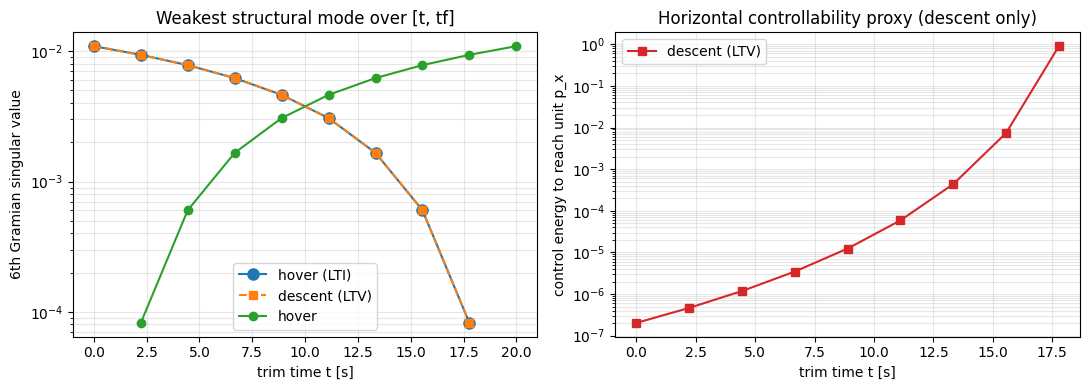

In [ ]:
rows = dyn.compare_along_trajectory(params)

t = [r["t"] for r in rows]
sigW_h = [r["sigma_struct_W_hover"] for r in rows]
sigW_d = [r["sigma_struct_W_descent"] for r in rows]
horiz_d = [r["horiz_index_descent"] for r in rows]

print("Remaining-horizon controllability along descent")
print("t[s]  rem[s]  sigma6_W(hover)  sigma6_W(descent)  horiz_energy(descent)")
for r in rows:
    print(
        f"{r['t']:5.1f} {r['remaining']:6.1f} "
        f"{r['sigma_struct_W_hover']:12.3e} {r['sigma_struct_W_descent']:12.3e} "
        f"{r['horiz_index_descent']:12.3e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Option A: different markers + zorder
axes[0].semilogy(t, sigW_h, "o-", label="hover (LTI)", markersize=8, zorder=2)
axes[0].semilogy(t, sigW_d, "s--", label="descent (LTV)", markersize=6, zorder=3)

axes[0].set_xlabel("trim time t [s]")
axes[0].set_ylabel("6th Gramian singular value")
axes[0].set_title("Weakest structural mode over [t, tf]")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].semilogy(t, horiz_d, "s-", color="C3", label="descent (LTV)")
axes[1].set_xlabel("trim time t [s]")
axes[1].set_ylabel("control energy to reach unit p_x")
axes[1].set_title("Horizontal controllability proxy (descent only)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [42]:
# Snapshot algebraic controllability at early vs late trim
for label, t_eval in [("early", 0.0), ("late", 15.0)]:
    A_h, B_h = dyn.get_hover_dynamics(t_eval, params)
    A_d, B_d = dyn.get_descent_dynamics(t_eval, params)
    s_h = dyn.singular_values(dyn.controllability_matrix(A_h, B_h))
    s_d = dyn.singular_values(dyn.controllability_matrix(A_d, B_d))
    trim = dyn.descent_trim(t_eval, params)
    print(f"\n{label} trim t={t_eval}s: m={trim['m']:.2f} kg, v_x*={trim['vx']:.1f} m/s, v_z*={trim['vz']:.1f} m/s")
    print("hover C singular values :", np.array2string(s_h, precision=3, suppress_small=True))
    print("descent C singular values:", np.array2string(s_d, precision=3, suppress_small=True))


early trim t=0.0s: m=20.00 kg, v_x*=40.0 m/s, v_z*=-8.0 m/s
hover C singular values : [0.98  0.98  0.1   0.1   0.051 0.049 0.   ]
descent C singular values: [0.98  0.98  0.1   0.1   0.051 0.049 0.   ]

late trim t=15.0s: m=9.59 kg, v_x*=25.0 m/s, v_z*=-8.0 m/s
hover C singular values : [0.98  0.98  0.1   0.1   0.051 0.049 0.   ]
descent C singular values: [0.98  0.98  0.107 0.102 0.1   0.1   0.   ]


## Part I.5.3–5.5 — LQR regulation, cost tuning, and linearization comparison

We now solve the **fixed-time, free-endpoint regulation** problem from Section 5.3 for both linearizations:

$$
\min_u \int_0^{t_f} (x^\top Q x + u^\top R u)\,dt + x(t_f)^\top Q_f x(t_f).
$$

**Section 5.5 asks for two analyses:**

1. **Cost-matrix sweep** — compare diagonal $Q$, $R$, $Q_f$ (and optionally identity costs in *scaled* coordinates) to find weights that produce physically reasonable “good” trajectories.
2. **Controllable vs weakly controllable** — with a fixed cost, compare **hover LTI** (Section 5.1) vs **descent LTV** (Section 5.2) on initial-condition sensitivity, control energy, and transients.

Reusable helpers live in `analysis.py`; the Riccati solver remains in `lqr.py`.

In [ ]:
sys.modules.pop("lqr", None)
sys.modules.pop("analysis", None)
sys.modules.pop("experiments", None)
import lqr
import analysis as ana
import experiments as exp

tf = params["tf_descent"]
t_lqr = exp.default_time_grid(params)

x0_reg = exp.DEFAULT_X0_REG.copy()
delta_x0 = exp.DEFAULT_DELTA_X0.copy()

print("Reference state scales (nondimensionalization):")
for lab, s in zip(ana.STATE_LABELS, ana.DEFAULT_REFERENCE_SCALES):
    print(f"  {lab:>3}: {s}")
print(f"\n||x0_reg|| = {np.linalg.norm(x0_reg):.2f}")

print(
    "\nForward rollouts use constraints.py: PMP control saturation "
    "and numerical state truncation (p_z >= 0, m >= m_dry)."
)


### 5.5 (i) — Compare $Q$, $R$, $Q_f$ choices (hover LTI)

We sweep several **diagonal** presets plus an **identity-in-scaled-coordinates** choice. In scaled variables $\tilde x_i = x_i / x_{i,\mathrm{ref}}$, taking $Q = Q_f = I$ is natural; mapped back to physical units this is $Q_{ii} = 1/x_{i,\mathrm{ref}}^2$.

**Trajectory quality heuristics** (for picking weights used in Part II):
- terminal state norm $\|x(t_f)\|$ small
- no excessive control peaks or saturation risk
- smooth decay of $\sqrt{x^\top Q x}$ (no large overshoot in attitude/position)

In [ ]:
hover_rows = ana.sweep_cost_presets(
    dyn.get_hover_dynamics, t_lqr, x0_reg, params, include_scaled_identity=True
)

print(f"{'preset':<18} {'J':>10} {'E_u':>10} {'||x(tf)||':>10} {'peak||x||':>10} {'t_settle':>8}")
for r in hover_rows:
    print(
        f"{r['preset']:<18} {r['J']:10.1f} {r['control_energy']:10.1f} "
        f"{r['terminal_state_norm']:10.3f} {r['peak_state_norm']:10.3f} {r['settle_time']:8.2f}"
    )

# Pick the preset with smallest terminal norm (tie-break on cost)
best = min(hover_rows, key=lambda r: (r["terminal_state_norm"], r["J"]))
Q, R, Qf = ana.cost_from_preset(best["preset"])
print(f"\nSelected for downstream comparison: '{best['preset']}'")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(hover_rows)))

for r, c in zip(hover_rows, colors):
    axes[0, 0].plot(r["t_eff"], r["state_norm_trace"], color=c, alpha=0.8, label=r["preset"])
    axes[0, 1].plot(r["t_eff"], r["weighted_state_trace"], color=c, alpha=0.8)
    axes[1, 0].plot(r["t_eff"], np.linalg.norm(r["u_hist"], axis=1), color=c, alpha=0.8)
    axes[1, 1].plot(r["x_hist"][:, 0], r["x_hist"][:, 1], color=c, alpha=0.8)

axes[0, 0].set(xlabel="t [s]", ylabel=r"$\|x\|$", title="State norm transient")
axes[0, 1].set(xlabel="t [s]", ylabel=r"$\sqrt{x^\top Q x}$", title="Weighted state norm")
axes[1, 0].set(xlabel="t [s]", ylabel=r"$\|u\|$", title="Control magnitude")
axes[1, 1].set(xlabel="$p_x$", ylabel="$p_z$", title="Mission-plane trajectories")
axes[1, 1].axis("equal")
axes[0, 0].legend(fontsize=7, ncol=2)
for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 (ii) — Controllable vs weakly controllable linearizations

Using the selected cost matrices, we compare:

| Metric | Hover LTI (5.1) | Descent LTV (5.2) |
|--------|-----------------|-------------------|
| IC sensitivity | terminal $\|x(t_f)\|$ vs perturbation scale $\alpha$ | same |
| Control energy | $\int_0^{t_f} \|u\|^2\,dt$ | same |
| Transients | $\|x(t)\|$, $\sqrt{x^\top Q x}$ | expect slower/weaker horizontal correction |

The descent plant is **time-varying** and **weakly controllable in $p_x$** (thrust cannot push horizontally at $\theta^*\approx 0$), so the same LQR weights should produce **higher cost, more control effort, and larger terminal error** under identical initial perturbations.

In [ ]:
alphas = np.linspace(0.25, 2.0, 8)
cmp = ana.compare_linearizations(
    dyn.get_hover_dynamics,
    dyn.get_descent_dynamics,
    t_lqr,
    Q,
    R,
    Qf,
    x0_reg,
    params,
    ic_alphas=alphas,
    delta_x0=delta_x0,
)

mh, md = cmp["hover"]["metrics"], cmp["descent"]["metrics"]
print("Single-IC comparison (same x0_reg, same Q/R/Qf)")
print(f"{'model':<12} {'J':>10} {'E_u':>10} {'||x(tf)||':>10} {'peak||x||':>10} {'t_settle':>8}")
for label, m in [("hover LTI", mh), ("descent LTV", md)]:
    print(
        f"{label:<12} {m['J']:10.1f} {m['control_energy']:10.1f} "
        f"{m['terminal_state_norm']:10.3f} {m['peak_state_norm']:10.3f} {m['settle_time']:8.2f}"
    )

xh, uh = cmp["hover"]["x_hist"], cmp["hover"]["u_hist"]
xd, ud = cmp["descent"]["x_hist"], cmp["descent"]["u_hist"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(cmp["hover"]["t_eff"], mh["state_norm_trace"], "C0-", label="hover")
axes[0, 0].plot(cmp["descent"]["t_eff"], md["state_norm_trace"], "C3--", label="descent")
axes[0, 0].set(xlabel="t [s]", ylabel=r"$\|x\|$", title="Transient: state norm")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(cmp["hover"]["t_eff"], mh["weighted_state_trace"], "C0-", label="hover")
axes[0, 1].plot(cmp["descent"]["t_eff"], md["weighted_state_trace"], "C3--", label="descent")
axes[0, 1].set(xlabel="t [s]", ylabel=r"$\sqrt{x^\top Q x}$", title="Weighted transient")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(cmp["hover"]["t_eff"], mh["control_norm_trace"], "C0-", label="hover")
axes[1, 0].plot(cmp["descent"]["t_eff"], md["control_norm_trace"], "C3--", label="descent")
axes[1, 0].set(xlabel="t [s]", ylabel=r"$\|u\|$", title="Control energy proxy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(xh[:, 0], xh[:, 1], "C0-", lw=2, label="hover")
axes[1, 1].plot(xd[:, 0], xd[:, 1], "C3--", lw=2, label="descent")
axes[1, 1].scatter([x0_reg[0]], [x0_reg[1]], c="k", s=40, zorder=5, label="$x_0$")
axes[1, 1].set(xlabel="$p_x$", ylabel="$p_z$", title="Mission-plane regulation")
axes[1, 1].axis("equal")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Selected-state transients (horizontal + attitude channels)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, lab in zip([0, 2, 4], ["$p_x$", "$v_x$", r"$\theta$"]):
    axes[i].plot(cmp["hover"]["t_eff"], xh[:, i if i != 2 else 2], "C0-", label="hover")
    axes[i].plot(cmp["descent"]["t_eff"], xd[:, i if i != 2 else 2], "C3--", label="descent")
    axes[i].set(xlabel="t [s]", ylabel=lab)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend()
plt.suptitle("Weakly controllable directions: horizontal & attitude transients", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# IC sensitivity: x0(alpha) = x0_reg + alpha * delta_x0
ic_h = cmp["ic_sensitivity"]["hover"]
ic_d = cmp["ic_sensitivity"]["descent"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(alphas, [r["terminal_state_norm"] for r in ic_h], "o-", label="hover")
axes[0].plot(alphas, [r["terminal_state_norm"] for r in ic_d], "s--", label="descent")
axes[0].set(xlabel=r"IC scale $\alpha$", ylabel=r"$\|x(t_f)\|$", title="Terminal error vs IC perturbation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, [r["control_energy"] for r in ic_h], "o-", label="hover")
axes[1].plot(alphas, [r["control_energy"] for r in ic_d], "s--", label="descent")
axes[1].set(xlabel=r"IC scale $\alpha$", ylabel=r"$\int \|u\|^2 dt$", title="Control energy vs IC perturbation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(alphas, [r["J"] for r in ic_h], "o-", label="hover")
axes[2].plot(alphas, [r["J"] for r in ic_d], "s--", label="descent")
axes[2].set(xlabel=r"IC scale $\alpha$", ylabel="$J$", title="LQR cost vs IC perturbation")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways for Part II

- Export the chosen `Q`, `R`, `Qf` (from the cost sweep) into `p2_tracking.ipynb` when generating the reference trajectory.
- The **hover LTI** linearization is the right default for Part II tracking Riccati integration; the **descent LTV** case shows why late-horizon horizontal errors are hard to correct (consistent with the Gramian analysis above).
- To explore more weights, add entries to `COST_PRESETS` in `analysis.py` or pass custom diagonals through `ana.diagonal_cost(...)`.

### Why we plot the 6th singular value (not the 7th)

The 7-state system has 7 singular values. The **7th (smallest)** is the near-zero **mass mode**: fuel can only be burned, not restored, so that direction is structurally uncontrollable. Its numerical value hovers around machine zero and can cross filtering thresholds unpredictably — that caused the kink in the old hover Gramian plot.

The **6th singular value** is the weakest **physically meaningful** controllable direction (typically horizontal / attitude-coupled). That is the mode whose deterioration matters for the mission.

### Why controllability deteriorates along descent

At $\theta^* \approx 0$, thrust cannot directly accelerate horizontally ($B_{v_x,\delta T}=\sin\theta^*/m \approx 0$). Horizontal motion is controlled only through $\tau \rightarrow \omega \rightarrow \theta \rightarrow v_x \rightarrow p_x$.

**Along the trajectory**, the key effect is the **shrinking remaining horizon** $[t, t_f]$:
- Early in descent you have ~20 s to steer all states.
- Near landing you may have only a few seconds left, so the 6th Gramian singular value drops sharply.
- The horizontal-energy proxy (descent only) grows by orders of magnitude as $t \to t_f$.

The horizontal proxy is plotted for **descent only** because hover has $v_x^*=0$ — there is no large horizontal-speed problem to manage, even though the linearized matrices are similar at $\theta^*=0$.

### Legacy sweep-method cells removed

The duplicate `solve_finite_horizon_lqr` implementation (with a different Riccati scaling) has been removed. All Part I regulation uses `analysis.run_regulation` → `lqr.py`, with constraints enforced in `constraints.py` during the forward pass.
